# The HFM library - A fast marching solver with adaptive stencils

## Part : Non holonomic metrics and curvature penalization
## Chapter : Convexity enforcing models

We consider variants of the curvature penalized path models which enforce convexity. They are obtained by simple modifications of the Hamiltonian of the eikonal PDE, which only propagate the front in the direction of increasing angles. In addition, a wall can be introduced in the computational domain to ensure that the angle does not increase by more than $2 \pi$.

The parameter $\xi$ should be regarded as a typical radius of curvature, and dictates the intensity of curvature penalization.

**Convex Euler-Mumford elastica model.**
It is defined by the Hamiltonian 
$$
    H_\theta(\hat p) = \frac 3 8 \int_0^{\pi/2} <\hat p,e(\theta,\phi)>_+^2 \cos \phi\, d \phi. 
$$
where $(x,\theta) \in R^2 \times S^1$ is the current state, $\hat p$ is a co-vector at this point, and $e(\theta,\phi) := (\cos \theta \cos \phi,\sin \theta\cos \phi,\xi^{-1}\sin\phi)$.

For comparison, the Hamiltonian of the usual Euler-Mumford elastica model is defined by a similar expression where the integral ranges over $[-\pi/2,\pi/2]$.
The Lagrangian $L_\theta$ is defined by Legendre-Fenchel duality from the Hamiltonian, and the metric is $F_\theta := \sqrt{2L_\theta}$. Interestingly, they admit a closed form expression.

The convex elastica model *cannot* produce straight lines, and *cannot* produce angles. Both have a cost of $+\infty$.

**Convex Reeds-Shepp forward model.**
It is defined by the Hamiltonian
$$
    2 H_\theta(\hat x,\hat \theta) :=  <\hat x,e(\theta)>_+^2 + \xi^{-2} \hat \theta_+^2,
$$
where $(x,\theta) \in R^2 \times S^1$ is the current state, $(\hat x,\hat \theta)$ is a co-vector at this point, and $e(\theta) := (\cos \theta ,\sin \theta)$.

For comparison, the Hamiltonian of the usual Reeds-Shepp model is defined by a similar expression, except for the term $\hat \theta^2$ (in place of $\hat \theta_+^2).

The convex Reeds-Shepp model can produce straight lines, and can produce angles.

**Convex Dubins model.**
It is defined by the Hamiltonian
$$
    2 H_\theta(\hat x,\hat \theta) = <\hat x,e(\theta)> + \xi^{-1}
$$


The convex Dubins model can produce straight lines, but cannot produce angles. In fact, the radius of curvature of these trajectories is bounded below by $\xi$.

[**Summary**](Summary.ipynb) of volume Fast Marching Methods, this series of notebooks.

[**Main summary**](../Summary.ipynb) of the Adaptive Grid Discretizations 
	book of notebooks, including the other volumes.

# Table of contents
  * [1. Convex geodesics in free space](#1.-Convex-geodesics-in-free-space)
    * [1.1 Original models](#1.1-Original-models)
    * [1.2 Convex variants](#1.2-Convex-variants)
  * [2. Journey from a point to itself](#2.-Journey-from-a-point-to-itself)
    * [2.1 Perturbation of position](#2.1-Perturbation-of-position)
    * [2.2 Perturbation of orientation](#2.2-Perturbation-of-orientation)



This Python&reg; notebook is intended as documentation and testing for the [HamiltonFastMarching (HFM) library](https://github.com/mirebeau/HamiltonFastMarching), which also has interfaces to the Matlab&reg; and Mathematica&reg; languages. 
More information on the HFM library in the manuscript:
* Jean-Marie Mirebeau, Jorg Portegies, "Hamiltonian Fast Marching: A numerical solver for anisotropic and non-holonomic eikonal PDEs", 2019 [(link)](https://hal.archives-ouvertes.fr/hal-01778322)

Copyright Jean-Marie Mirebeau, University Paris-Sud, CNRS, University Paris-Saclay


## 0. Importing the required libraries

In [85]:
import sys; sys.path.insert(0,"../..") # Allow import of agd from parent directory (useless if conda package installed)
#from Miscellaneous import TocTools; print(TocTools.displayTOC('ConvexCurvature','FMM'))

In [2]:
from agd import Eikonal
from agd import AutomaticDifferentiation as ad
from agd.Plotting import savefig, SetTitle3D; #savefig.dirName = 'Figures/Curvature/'

In [3]:
import numpy as np; xp=np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Plots 3D paths

useMayavi = False
if useMayavi:
    from mayavi import mlab # Plots implicit surfaces

In [4]:
def ReloadPackages():
    from Miscellaneous.rreload import rreload
    global Eikonal,ad
    Eikonal,ad = rreload([Eikonal,ad],rootdir='../..')

### 0.1 Additional configuration

The experiments presented in this notebook require the GPU accelerated solver. 
(Adapting them for the cpu solver would not be too difficult, although computation times would be longer.)

In [5]:
if ad.cupy_generic.cp is None: raise ad.DeliberateNotebookError("cupy module not found")

In [6]:
xp,Eikonal,plt = [ad.cupy_friendly(e) for e in (xp,Eikonal,plt)]

Replacing numpy with cupy, set to output 32bit ints and floats by default.
Using cp.asarray(*,dtype=np.float32) as the default caster in ad.array.
Setting dictIn.default_mode = 'gpu' in module agd.Eikonal .
Returning a copy of module matplotlib.pyplot whose functions accept cupy arrays as input.


## 1. Convex geodesics in free space

We consider here the models with a constant cost function, and a without any obstacles.

### 1.1 Original models

Note that the Reeds-Shepp forward model has in-place rotations at the beginning and end.

In [8]:
hfmIn = Eikonal.dictIn({
    'model':'Elastica2',
    'xi':0.4,
    'seed': (1,0,0),
    'tips': [(-1,0.5,0),(-1,-0.5,0)],
})

hfmIn.SetRect([[-2,2],[-1,1]],dimx=200)
hfmIn.nTheta = 100

Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.08641624450683594 seconds, and 100 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.3031892776489258 seconds, and 272 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.12404465675354004 seconds, and 165 iterations.
Post-Processing


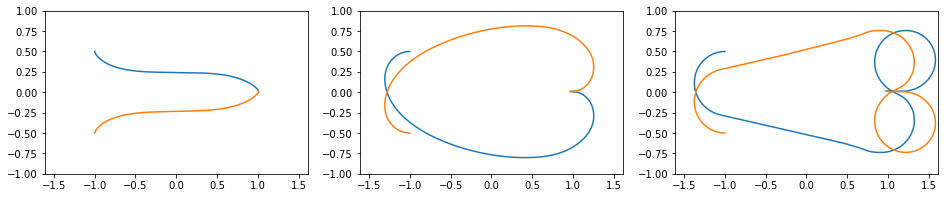

In [9]:
plt.figure(figsize=[16,3])
for i,model in enumerate(('ReedsSheppForward2','Elastica2','Dubins2')):
    hfmIn['model'] = model
    hfmOut = hfmIn.Run()
    ax = plt.subplot(1,3,i+1)
    plt.title(model); plt.axis('equal')
    ax.set_xlim(-2,2); ax.set_ylim(-1,1); 
    for geo in hfmOut['geodesics']:  plt.plot(geo[0],geo[1])

### 1.2 Convex variants

We use the `convex_curvature_macro` trait parameter to forbid rotation on the left, and make the following observations
- both paths are modified for the Reeds-Shepp forward model. Indeed, the original path had both convex and concave parts.
- one path is strongly modified for the Euler-Mumford elastica model. The second path is also likely slightly modified, due to the modification of the Hamiltonian, but it is harder to see.
- only one path is modified for the Dubins model.

<!---the paths of the Euler-Eumford elastica model make several turns, hence are not part of the boundar of a convex set. This is an issue that needs to be addressed. --->

In [10]:
hfmIn = Eikonal.dictIn({
    'model':'Elastica2',
    'seed': (1,0,0),
    'tips': [(-1,0.5,0),(-1,-0.5,0)],
    'xi':0.4,
    'traits':{'convex_curvature_macro':True},
})

hfmIn.SetRect([[-2,2],[-1.5,1.5]],dimx=200)
hfmIn.nTheta = 100

Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.12058234214782715 seconds, and 123 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.3510613441467285 seconds, and 328 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.2967064380645752 seconds, and 255 iterations.
Post-Processing


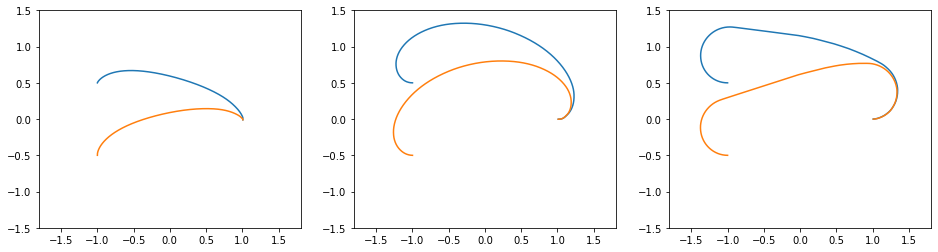

In [11]:
plt.figure(figsize=[16,4])
for i,model in enumerate(('ReedsSheppForward2','Elastica2','Dubins2')):
    hfmIn['model'] = model
    hfmOut = hfmIn.Run()
    ax = plt.subplot(1,3,i+1)
    plt.title(model," convex variant"); plt.axis('equal')
    ax.set_xlim(-2,2); ax.set_ylim(-1.5,1.5); 
    for geo in hfmOut['geodesics']:  plt.plot(geo[0],geo[1])

## 2. Journey from a point to itself 

If the seed and tip are the same point, then the HFM library returns a path of length zero, which is not a very informative result. Instead, in order to obtain a non-trivial path, we need to use a perturbation.

### 2.1 Perturbation of position

We use adjacent points on the discretization grid for the seed and tip, with identical physical position, and orientation differing by one. We first consider the original models.

<!---
aX,aY,aθ = hfmIn.Axes()
X,Y = np.meshgrid(aX,aY,indexing='ij')
#hfmIn['walls'] = (np.abs(X+0.05)<=dx/2) & (np.abs(Y)<0.3)

nX,nθ = 201,100

--->

In [76]:
hfmIn = Eikonal.dictIn({
    'model':'Elastica2',
    'xi':0.4,
    'seed':(0,0,0),
    'pastseed_delay':100, # Use if seed and tip are close 
    #(disables the PastSeed backtracking stopping criterion for a number of initiabl steps)
})

hfmIn.SetRect([[-1,1],[-1,1]],dimx=201)
hfmIn.nTheta = 100
dx = hfmIn.gridScales[0]
hfmIn['tip'] = (-dx,0,0)

Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.1403048038482666 seconds, and 97 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.48948097229003906 seconds, and 284 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.18111610412597656 seconds, and 172 iterations.
Post-Processing


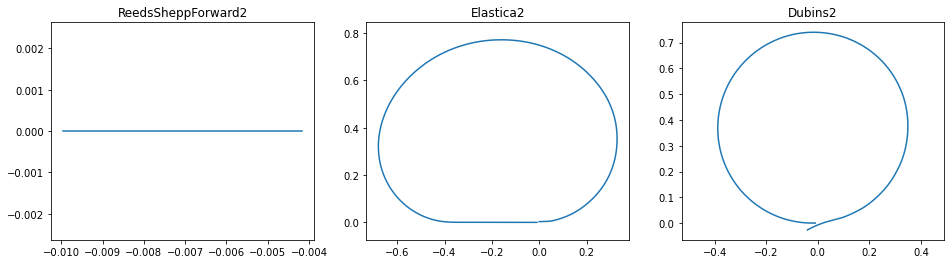

In [77]:
plt.figure(figsize=[16,4])
for i,model in enumerate(('ReedsSheppForward2','Elastica2','Dubins2')):
    hfmIn['model'] = model
    hfmOut = hfmIn.Run()
    ax = plt.subplot(1,3,i+1)
    plt.title(model); plt.axis('equal')
    for geo in hfmOut['geodesics']:  plt.plot(geo[0],geo[1])    

The geodesic associated the `ReedsSheppForward` model is almost stationnary in physical space. In fact it converges to a pure rotation  as the seed and tip move toward each other. (In this example, by $\pi$, then by $-\pi$.)

The other two geodesics should converge to circles as the seed and tip points move toward each other. There is substantial numerical error, due in part to the following difficulty : the tip belongs to the cut locus, and two tangent geodesics meet there, corresponding to the circle above and below.

In [80]:
hfmIn['model']='ReedsSheppForward2'
hfmOut = hfmIn.Run()
geo = hfmOut['geodesics'][0]
geo[:,::10] # Pure rotation in angular space

Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.14000701904296875 seconds, and 97 iterations.
Post-Processing


array([[-0.00995028, -0.00995028, -0.00995028, -0.00995028, -0.00995028,
        -0.00995028, -0.00995028, -0.00995028, -0.00995028, -0.00995028,
        -0.00995028, -0.00995028, -0.00995028, -0.00995028, -0.00995028,
        -0.00995028, -0.00995028, -0.00890255, -0.00417143, -0.00417143,
        -0.00417143, -0.00417143, -0.00417143, -0.00417143, -0.00417143,
        -0.00417143, -0.00417143, -0.00417143, -0.00417143, -0.00417143,
        -0.00417143, -0.00417143, -0.00417143, -0.00417143, -0.00417143,
        -0.00417143, -0.00417143, -0.00417143, -0.00417143, -0.00417143],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.

The "convex curvature" variants of the models with circle above rather than below. 
Also the circle is rounder, for the Elastica and Dubins models, because the tip is not in the cut locus.

Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.14575576782226562 seconds, and 129 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.40965723991394043 seconds, and 370 iterations.
Post-Processing
Setting the kernel traits.
Preparing the domain data (shape,metric,...)
Preparing the problem rhs (cost, seeds,...)
Preparing the GPU kernel
Running the eikonal GPU kernel
GPU kernel eikonal ran for 0.24135422706604004 seconds, and 295 iterations.
Post-Processing


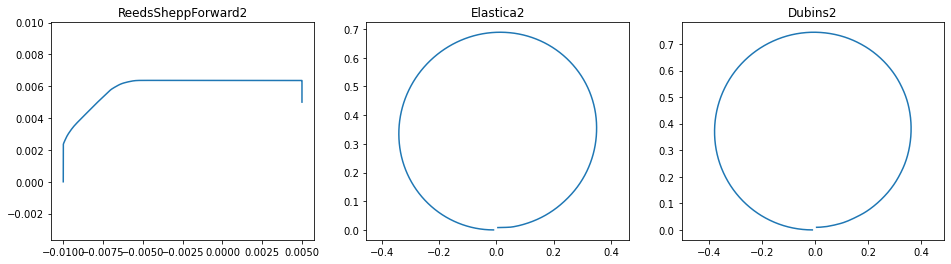

In [48]:
hfmIn['traits']={'convex_curvature_macro':True}

plt.figure(figsize=[16,4])
for i,model in enumerate(('ReedsSheppForward2','Elastica2','Dubins2')):
    hfmIn['model'] = model
    hfmOut = hfmIn.Run()
    ax = plt.subplot(1,3,i+1)
    plt.title(model); plt.axis('equal')
    for geo in hfmOut['geodesics']:  plt.plot(geo[0],geo[1])    

### 2.2 Perturbation of orientation

We put a slightly positive orientation for the seed, and a slightly negative orientation for the tip. A wall is also introduced to exclude the horizontal orientation.

In [66]:
_,_,dθ = hfmIn.gridScales
_,_,aθ = hfmIn.Axes()
hfmIn.update({
    'seed':(0,0,dθ),
    'tip': (0,0,-dθ),
    'walls': aθ==0,
    'verbosity':0,
})

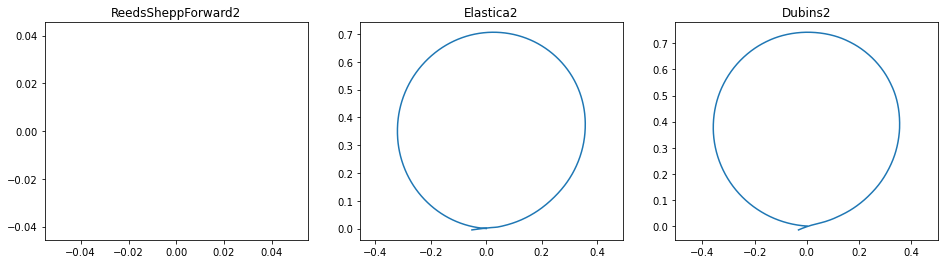

In [69]:
hfmIn['traits']={'convex_curvature_macro':False}
plt.figure(figsize=[16,4])
for i,model in enumerate(('ReedsSheppForward2','Elastica2','Dubins2')):
    hfmIn['model'] = model
    hfmOut = hfmIn.Run()
    ax = plt.subplot(1,3,i+1)
    plt.title(model); plt.axis('equal')
    for geo in hfmOut['geodesics']:  plt.plot(geo[0],geo[1])    

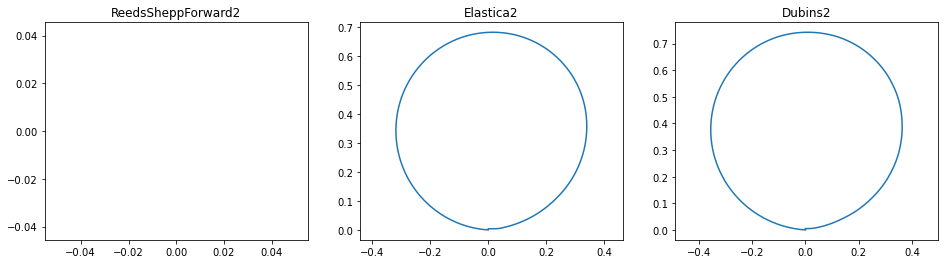

In [70]:
hfmIn['traits']={'convex_curvature_macro':True}
plt.figure(figsize=[16,4])
for i,model in enumerate(('ReedsSheppForward2','Elastica2','Dubins2')):
    hfmIn['model'] = model
    hfmOut = hfmIn.Run()
    ax = plt.subplot(1,3,i+1)
    plt.title(model); plt.axis('equal')
    for geo in hfmOut['geodesics']:  plt.plot(geo[0],geo[1])    

As before, the ReedsSheppForward path performs an in-place rotation by $2\pi$. Note that paths are backtracked, hence the tip comes first, and the seed comes last, in the table below.

In [72]:
hfmIn['model']='ReedsSheppForward2'
hfmOut = hfmIn.Run()
geo = hfmOut['geodesics'][0]
geo[:,::10] # Pure rotation in angular space

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.